In [2]:
import kafou_arraylake as arraylake 
import xarray as xr

SOURCE_REPO = "kafou/aurora-era5-forecast-lv-6z-rollout-geo-uk"
SOURCE_BRANCH = "main"

client = arraylake.Client()
repo = client.get_repo(SOURCE_REPO)
session = repo.readonly_session(SOURCE_BRANCH)

ds_lv = xr.open_zarr(session.store, zarr_format=3, consolidated=False, chunks=None)

print(ds_lv)

#lv = ds_lv["lv"].values


init_time = 365 * 10 # days * years
lead_time = 7   # steps
spatial_location = 1024
feature = 1024

lv = init_time * lead_time * spatial_location * feature * 4

((lv / 1024**2 ) / 1024 ) * 1.07374 # GB

<xarray.Dataset> Size: 133GB
Dimensions:           (feature: 1024, init_time: 3974, lead_time: 8,
                       spatial_location: 1024)
Coordinates:
  * feature           (feature) int64 8kB 0 1 2 3 4 ... 1019 1020 1021 1022 1023
    valid_time        (init_time, lead_time) datetime64[ns] 254kB ...
  * init_time         (init_time) datetime64[ns] 32kB 2015-01-01T06:00:00 ......
  * spatial_location  (spatial_location) int64 8kB 10428 10429 ... 209882 209883
  * lead_time         (lead_time) int64 64B 6 12 18 24 30 36 42 48
Data variables:
    lv                (init_time, lead_time, spatial_location, feature) float32 133GB ...
Attributes:
    description:          Aurora latent forecast dataset
    rollout_steps:        8
    valid_time_range:     ['2015-01-01T06:00:00.000000000', '2025-11-17T06:00...
    spatial_subset_type:  bounding_box
    lat_range_requested:  [46.5, 61.5]
    lon_range_requested:  [-11.5, 3.5]


107.16428515624999

In [3]:
written_mask = (
    ~xr.ufuncs.isnan(ds_lv["lv"])
    .any(dim=("lead_time", "spatial_location", "feature"))
)

written_init_times = ds_lv["init_time"].where(written_mask, drop=True)

written_init_times


KeyboardInterrupt: 

In [3]:
import zarr

lv = zarr.open_array(session.store, path="lv", zarr_format=3, mode="r")

lv[:1, :1, :1, :1]


array([[[[-0.17650236]]]], dtype=float32)

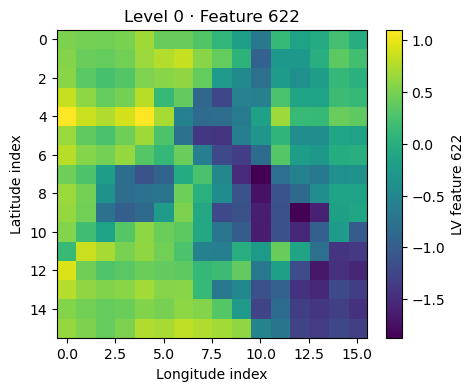

In [9]:
import matplotlib.pyplot as plt

arry = ds_lv["lv"].isel(init_time=2000, lead_time=0).values.reshape(4, 16, 16, 1024)
field = arry[0, :, :, 622]  # (lat, lon)

plt.figure(figsize=(5, 4))
plt.imshow(field, origin="upper", aspect="auto")
plt.colorbar(label="LV feature 622")
plt.title("Level 0 · Feature 622")
plt.xlabel("Longitude index")
plt.ylabel("Latitude index")
plt.show()


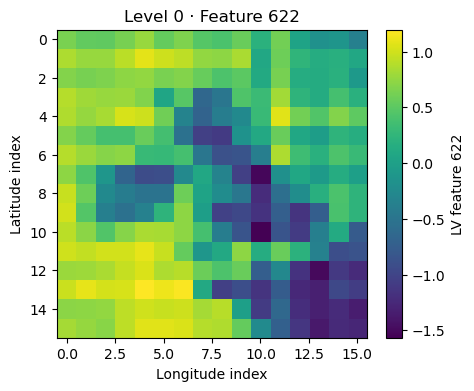

In [10]:
import matplotlib.pyplot as plt

arry = ds_lv["lv"].isel(init_time=300, lead_time=0).values.reshape(4, 16, 16, 1024)
field = arry[0, :, :, 622]  # (lat, lon)

plt.figure(figsize=(5, 4))
plt.imshow(field, origin="upper", aspect="auto")
plt.colorbar(label="LV feature 622")
plt.title("Level 0 · Feature 622")
plt.xlabel("Longitude index")
plt.ylabel("Latitude index")
plt.show()
